In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Part 2: Cox Regression Analysis and Diagnostics

## Question 2.1: Model Fitting and Inference

### Section A

In [2]:
from lifelines import CoxPHFitter

In [3]:
df = pd.read_csv("veteran.csv")
df

,trt,celltype,time,status,karno,diagtime,age,prior
0,1,squamous,72,1,60,7,69,0
1,1,squamous,411,1,70,5,64,10
2,1,squamous,228,1,60,3,38,0
3,1,squamous,126,1,60,9,63,10
4,1,squamous,118,1,70,11,65,10
...,...,...,...,...,...,...,...,...
132,2,large,133,1,75,1,65,0
133,2,large,111,1,60,5,64,0
134,2,large,231,1,70,18,67,10
135,2,large,378,1,80,4,65,0


In [4]:
cox_df = df[["time", "status", "age", "karno", "celltype", "trt"]].dropna().copy()

In [5]:
celltype_order = ["squamous", "smallcell", "adeno", "large"]

cox_df["celltype"] = pd.Categorical(
    cox_df["celltype"],
    categories=celltype_order,
    ordered=False
)

cox_df = pd.get_dummies(
    cox_df,
    columns=["celltype"],
    drop_first=True
)

In [6]:
cph = CoxPHFitter()

cph.fit(
    cox_df,
    duration_col="time",
    event_col="status"
)

<lifelines.CoxPHFitter: fitted with 137 total observations, 9 right-censored observations>

In [7]:
hr_table = cph.summary[[
    "exp(coef)",
    "exp(coef) lower 95%",
    "exp(coef) upper 95%",
    "p"
]].rename(columns={
    "exp(coef)": "Hazard ratio",
    "exp(coef) lower 95%": "95% CI lower",
    "exp(coef) upper 95%": "95% CI upper",
    "p": "p-value"
})

hr_table.round(3)

,Hazard ratio,95% CI lower,95% CI upper,p-value
covariate,,,,
age,0.991,0.973,1.009,0.334
karno,0.968,0.958,0.978,0.000
trt,1.354,0.905,2.026,0.141
celltype_smallcell,2.355,1.383,4.007,0.002
celltype_adeno,3.251,1.818,5.812,0.000
celltype_large,1.495,0.859,2.602,0.154


### Section B

The estimated hazard ratio for karno is 0.968. This means that a one-unit increase in the Karnofsky performance score is associated with multiplying the hazard of death by 0.968. In other words, each point in Karnofsky score lowers the hazard of death by aproximately 3.2%. The result is statisticly signifficant

### Section C

In [8]:
from scipy.stats import chi2

In [9]:
full_df = cox_df.copy()

full_cph = CoxPHFitter()
full_cph.fit(
    full_df,
    duration_col="time",
    event_col="status"
)

<lifelines.CoxPHFitter: fitted with 137 total observations, 9 right-censored observations>

In [10]:
reduced_df = cox_df.drop(columns=["age", "trt"]).copy()

reduced_cph = CoxPHFitter()
reduced_cph.fit(
    reduced_df,
    duration_col="time",
    event_col="status"
)

<lifelines.CoxPHFitter: fitted with 137 total observations, 9 right-censored observations>

In [11]:
loglik_full = full_cph.log_likelihood_
loglik_reduced = reduced_cph.log_likelihood_

lrt_stat = 2 * (loglik_full - loglik_reduced)
df_lrt = 2  

p_value = 1 - chi2.cdf(lrt_stat, df_lrt)

lrt_results = pd.DataFrame({
    "Full log-likelihood": [loglik_full],
    "Reduced log-likelihood": [loglik_reduced],
    "LRT statistic": [lrt_stat],
    "df": [df_lrt],
    "p-value": [p_value]
})

lrt_results.round(4)

,Full log-likelihood,Reduced log-likelihood,LRT statistic,df,p-value
0,-474.4578,-475.7632,2.6109,2,0.2711


 The likelihood ratio test comparing the full model to the reduced model gave a test statistic of 2.6109 and a p-value of 0.2711. Since the p-value is greater than 0.05, we fail to reject the null hypothesis that the coefficients for age and treatment are both equal to zero. Thus, age and trt do not need to be retained in the model.

## Question 2.2: Model Adequacy

### Section A

In [12]:
from lifelines.statistics import proportional_hazard_test

import contextlib
import io

In [13]:
selected_df = cox_df.drop(columns=["age", "trt"]).copy()

selected_cph = CoxPHFitter()
selected_cph.fit(
    selected_df,
    duration_col="time",
    event_col="status"
)

<lifelines.CoxPHFitter: fitted with 137 total observations, 9 right-censored observations>

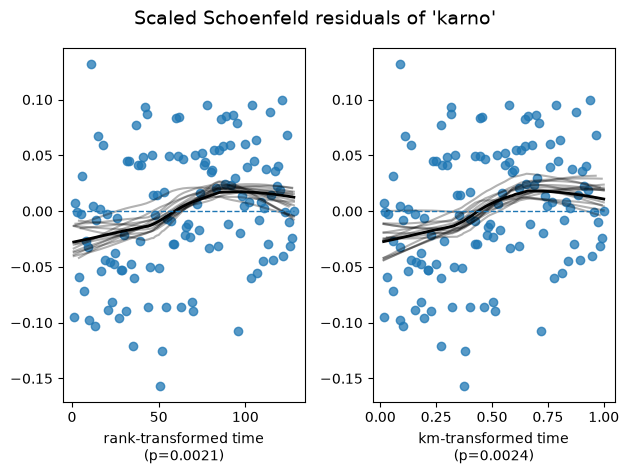

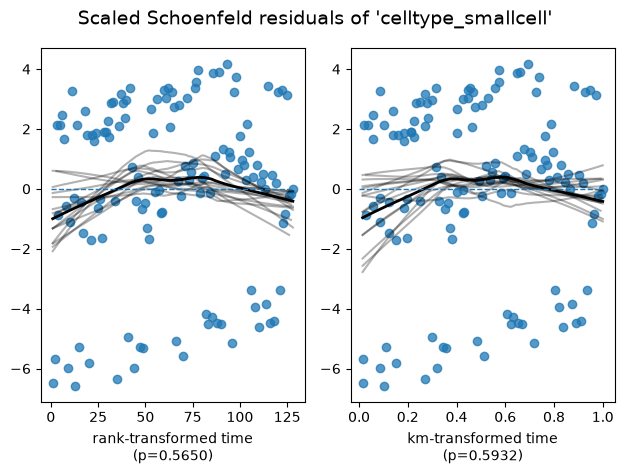

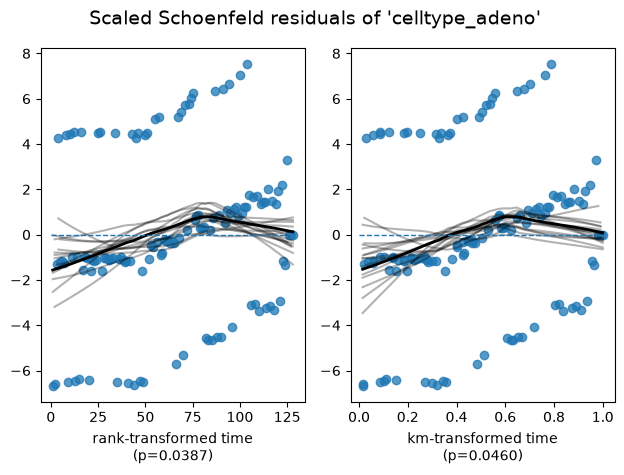

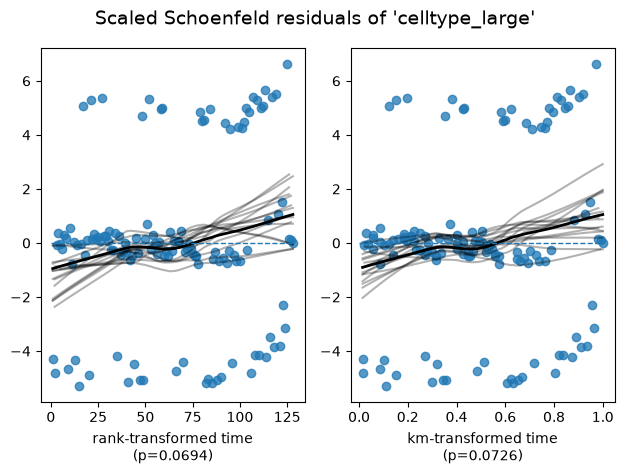

In [14]:
_buf = io.StringIO()

with contextlib.redirect_stdout(_buf):
    selected_cph.check_assumptions(
        selected_df,
        p_value_threshold=0.05,
        show_plots=True
    )



In [15]:
ph_test = proportional_hazard_test(
    selected_cph,
    selected_df,
    time_transform="rank"
)

ph_test.summary.round(4)

,test_statistic,p,-log2(p)
celltype_adeno,4.2750,0.0387,4.6924
celltype_large,3.2965,0.0694,3.8484
celltype_smallcell,0.3311,0.5650,0.8236
karno,9.4979,0.0021,8.9252


Since the likelihood ratio test in Question 2.1(c) did not reject the null hypothesis, we used the reduced Cox model.

If a residual plot exhibits a systematic trend over time, this suggests that the covariate’s effect on the hazard changes over time, meaning that the proportional hazards assumption may be violated.


### Section B

The formal Schoenfeld residual test rejected the null hypothesis for karno with p = 0.0021 and for celltype_adeno with p = 0.0387, meaning that there is evidence that the proportional hazards assumption  is violated.
The large cell type returns a p-value of 0.069 which technically does not reject the assumption at 0.05 significance level, although the result is somewhat close to the threshold.
Finally, the assumption holds for the small cell type, with p-value of 0.565. 

The Schoenfeld residual plots show an upward trend in karno, adeno cell type, and large cell type (not signifficant in the case of the large cell type). The small cell type plot is the closest to the straight line, with some resemblance to a "horseshoe", but not statistically signifficantly so. 

### Section C

The two covariates with statistically significant evidence of violation were karno and celltype_adeno.

In the case of the adeno cell type, a solution could be to stratify the model by celltype allowing each cell type to have its own baseline hazard, and loosing the adility to estimate hazart ratios accross different cell types.

For karno we will attemt to include a lime-dependant interaction between karno and, for example, log(t). This allows the effect of Karnofsky score on the hazard of death to change over follow-up time instead of forcing one constant hazard ratio

### Section D

In [16]:
strat_df = df[["time", "status", "karno", "celltype"]].dropna().copy()

strat_df.head()

,time,status,karno,celltype
0,72,1,60,squamous
1,411,1,70,squamous
2,228,1,60,squamous
3,126,1,60,squamous
4,118,1,70,squamous


In [17]:
strat_cph = CoxPHFitter()

strat_cph.fit(
    strat_df,
    duration_col="time",
    event_col="status",
    strata=["celltype"]
)

strat_cph.print_summary()

<lifelines.CoxPHFitter: fitted with 137 total observations, 9 right-censored observations>
             duration col = 'time'
                event col = 'status'
                   strata = celltype
      baseline estimation = breslow
   number of observations = 137
number of events observed = 128
   partial log-likelihood = -318.25
         time fit was run = 2026-06-23 13:16:42 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
karno     -0.04      0.97      0.01           -0.05           -0.02                0.95                0.98

           cmp to     z      p  -log2(p)
covariate                               
karno        0.00 -6.43 <0.005     32.86
---
Concordance = 0.69
Partial AIC = 638.50
log-likelihood ratio test = 40.97 on 1 df
-log2(p) of ll-ratio test = 32.59

In [18]:
strat_hr_table = strat_cph.summary[[
    "exp(coef)",
    "exp(coef) lower 95%",
    "exp(coef) upper 95%",
    "p"
]].rename(columns={
    "exp(coef)": "Hazard ratio",
    "exp(coef) lower 95%": "95% CI lower",
    "exp(coef) upper 95%": "95% CI upper",
    "p": "p-value"
})

strat_hr_table.round(3)

,Hazard ratio,95% CI lower,95% CI upper,p-value
covariate,,,,
karno,0.965,0.955,0.976,0.0


In [19]:
strat_ph_test = proportional_hazard_test(
    strat_cph,
    strat_df,
    time_transform="rank"
)

strat_ph_test.summary.round(4)

,test_statistic,p,-log2(p)
karno,2.8858,0.0894,3.4841


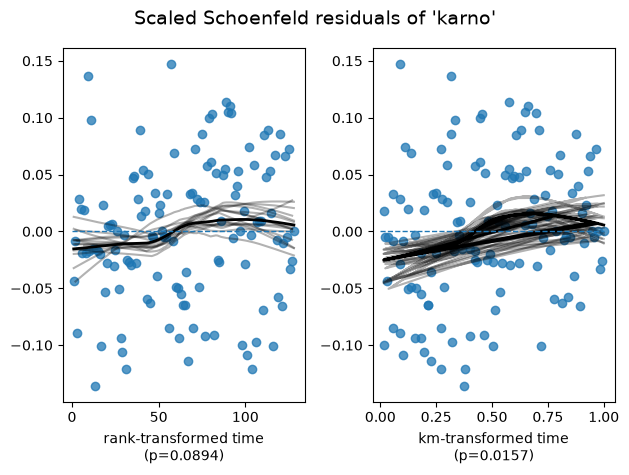

In [20]:
_buf = io.StringIO()

with contextlib.redirect_stdout(_buf):
    strat_cph.check_assumptions(
        strat_df,
        p_value_threshold=0.05,
        show_plots=True
    )

We implement the stratification for the categorical covariate cell type and refit the model. 

In this model, celltype is no longer included as an ordinary covariate. Instead, the model allows each cell type to have its own baseline hazard function. This means that the proportional hazards assumption is no longer required for comparisons between the cell type groups.

The fitted stratified Cox model estimated a hazard ratio of 0.965 for karno, with a 95% confidence interval of [0.955, 0.976] and p < 0.001. This means that, within a given cell type stratum, each one-point increase in Karnofsky performance score is associated with multiplying the hazard of death by 0.965, corresponding to approximately a 3.5% decrease in the hazard of death.

The residual diagnostics after stratification show that the cell type violation has been addressed by the stratified model, since cell type is no longer modeled through proportional hazard ratios. The remaining diagnostic plot for karno still shows some time trend, especially under the KM-transformed time test, so stratification resolves the categorical cell type issue but does not necessarily remove all possible time dependence related to Karnofsky score.

# Part 3: Competing Risks Analysis

In [21]:
aids_df = pd.read_csv('aidssi.csv')

## Question 3.1
### Section A

<Axes: xlabel='timeline'>

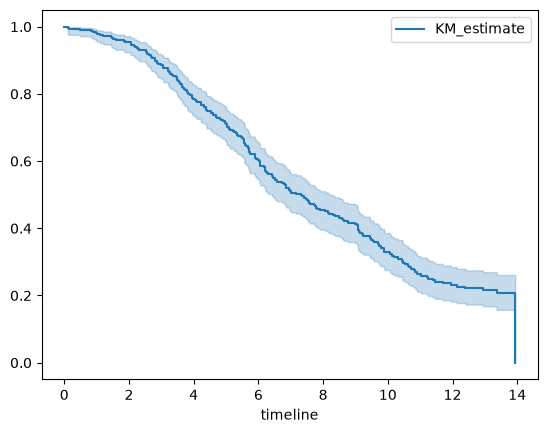

In [22]:
from lifelines import KaplanMeierFitter

km = KaplanMeierFitter()
km = km.fit(aids_df['time'], event_observed=aids_df['status'])
km.plot_survival_function()

### Section B

c:\Users\deeth\miniconda3\envs\SAML_env\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
c:\Users\deeth\miniconda3\envs\SAML_env\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(


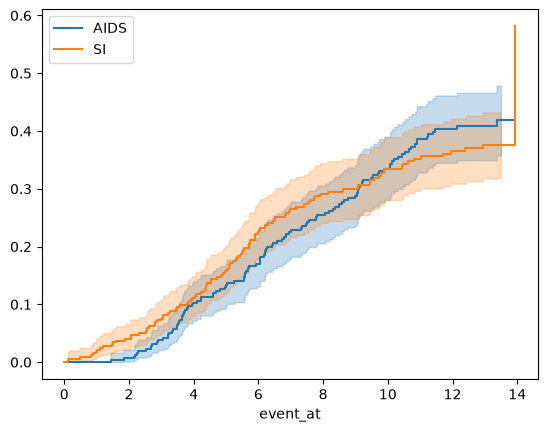

In [23]:
from lifelines import AalenJohansenFitter

aj1 = AalenJohansenFitter().fit(aids_df['time'], event_observed=aids_df['status'], event_of_interest=1)
aj2 = AalenJohansenFitter().fit(aids_df['time'], event_observed=aids_df['status'], event_of_interest=2)

aj1.plot_cumulative_density(label='AIDS')
aj2.plot_cumulative_density(label='SI')

### Section C

In [24]:
def aalen_johansen_cif(data, cause=1):
    data = data.sort_values("time").copy()
    event_times = np.sort(data.loc[data["status"] != 0, "time"].unique())
    rows = []
    S_prev = 1.0
    F = 0.0
    for t in event_times:
        R = (data["time"] >= t).sum()
        d_cause = ((data["time"] == t) & (data["status"] == cause)).sum()
        d_all = ((data["time"] == t) & (data["status"] != 0)).sum()
        increment = S_prev * d_cause / R
        F += increment
        rows.append({
            "time": t,
            "R(t)": R,
            "d_cause(t)": d_cause,
            "d_all(t)": d_all,
            "S(t-)": S_prev,
            "AJ_increment": increment,
            "CIF": F,
        })
        S_prev *= (1 - d_all / R)
    return pd.DataFrame(rows)



aj_cif_aids = aalen_johansen_cif(aids_df, cause=1)
aj_cif_si = aalen_johansen_cif(aids_df, cause=2)

In [25]:
times = [5, 10]

rows = []
for t in times:
    rows.append({
        "time": t,
        # probability of remaining event free is the survival function at time t
        "P(event free)": km.survival_function_at_times(t).values[0],
        # probability of experiencing AIDS by time t is the cumulative density function for AIDS at time t
        "P(AIDS)": aj_cif_aids.loc[aj_cif_aids['time'] <= t, 'CIF'].values[-1],
        # probability of experiencing SI by time t is the cumulative density function for SI at time t
        "P(SI)": aj_cif_si.loc[aj_cif_si['time'] <= t, 'CIF'].values[-1],
    })

res_c_df = pd.DataFrame(rows)
print(res_c_df.round(3))

   time  P(event free)  P(AIDS)  P(SI)
0     5          0.713    0.130  0.158
1    10          0.330    0.335  0.335


## Question 3.2
### Section A

In [26]:
from lifelines import CoxPHFitter

aids_df1 = aids_df.copy()
aids_df1['event'] = (aids_df1['status'] == 1).astype(int)
aids_df1['ccr5_dummy'] = (aids_df1['ccr5'] == 'WM').astype(int)

cph1 = CoxPHFitter().fit(aids_df1[['time', 'event', 'ccr5_dummy']], duration_col='time', event_col='event')

rename_hr = {'exp(coef)': 'HR', 'exp(coef) lower 95%': 'HR lower 95%', 'exp(coef) upper 95%': 'HR upper 95%'}
cph1_res = cph1.summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%']].rename(columns=rename_hr)
print(cph1_res.round(3))

              HR  HR lower 95%  HR upper 95%
covariate                                   
ccr5_dummy  0.29         0.159         0.529


The AIDS-specific Cox model estimates the HR as 0.3, with CI of [0.16, 0.53]. This means that the hazard of AIDS is 70% lower for patients with a mutant allele on one chromosome, and we are 95% confident that the true HR lies between 0.16 and 0.53 (not including 1, which indicates a significant effect).

### Section B

In [27]:
aids_df2 = aids_df.copy()
aids_df2['event'] = (aids_df2['status'] == 2).astype(int)
aids_df2['ccr5_dummy'] = (aids_df2['ccr5'] == 'WM').astype(int)

cph2 = CoxPHFitter().fit(aids_df2[['time', 'event', 'ccr5_dummy']], duration_col='time', event_col='event')
cph2_res = cph2.summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%']].rename(columns=rename_hr)
print(cph2_res.round(3))

               HR  HR lower 95%  HR upper 95%
covariate                                    
ccr5_dummy  0.769         0.482         1.225


The SI-specific Cox model estimates the HR as 0.77, with CI of [0.48, 1.2]. This means that the hazard of SI is 23% lower for patients with a mutant allele on one chromosome, but the CI includes 1, which indicates that the effect is not statistically significant.

### Section D

In [28]:
# compare results
cph_res = pd.concat([cph1_res, cph2_res], keys=['AIDS', 'SI'])
print(cph_res.round(3))

                    HR  HR lower 95%  HR upper 95%
     covariate                                    
AIDS ccr5_dummy  0.290         0.159         0.529
SI   ccr5_dummy  0.769         0.482         1.225


Overall, the results suggest that the presence of a mutant allele on one chromosome is associated with lower hazard ratio of AIDS, indicate by the smaller than 1 HR estimates in both models. However, the effect is only statistically significant for the AIDS-specific Cox model, as the CI does not include 1. The SI-specific Cox model does not show a significant effect, as the CI includes 1. So the effect appears similar in direction, but can only be confirmed for AIDS.

# Part 4: Discrete-Time Survival Analysis

In [29]:
rossi_df_csv = pd.read_csv('Rossi.csv')

## Question 4.1
### Section a

In [30]:
def rossi_to_person_week(rossi_df):
    baseline_covariates = ['fin', 'age', 'race', 'wexp', 'mar', 'paro', 'prio']
    person_week_rows = []
    for _, row in rossi_df.iterrows():
        for week in range(1, row['week'] + 1):
            person_week_rows.append({
                'id': row['ID'],
                'week': week,
                'event': int(week == row['week'] and row['arrest'] == 1),
                'emp': int(row[f'emp{week}']== 'yes'),
                # baseline covariates
                **{cov: row[cov] for cov in baseline_covariates}
            })

    return pd.DataFrame(person_week_rows)


rossi_df = rossi_to_person_week(rossi_df_csv)      

### Section B

In [31]:
print("Number of subjects:", rossi_df['id'].nunique())
print("Total number of person-weeks:", len(rossi_df))
print("Number of rearrests:", rossi_df['event'].sum())
print(f"Precent of person-weeks in which individuals were employed: {rossi_df['emp'].mean()*100:.1f}%")

Number of subjects: 432
Total number of person-weeks: 19809
Number of rearrests: 114
Precent of person-weeks in which individuals were employed: 46.8%


### Section C
Employed is a time-dependent covariate, as it can change over time in a different way for each individual. This is contray to variables like age or prio (number of previous convictions), which are fixed at baseline and either do not change over time (prio changes only once the individual is rearrested) or change in a predictable way (age increases by 1 each year for all individuals, so measuring it once upon release is sufficient). In contrast, employment status can change multiple times and at different time points for different individuals, making it a time-dependent covariate.

## Question 4.2
### Section A

In [32]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

formula = 'event ~ C(week) + fin + age + race + wexp + mar + paro + prio + C(emp)'

logit_model = smf.glm(formula=formula, data=rossi_df, family=sm.families.Binomial(link=sm.families.links.Logit())).fit()

logit_res = logit_model.summary2().tables[1][['Coef.', 'Std.Err.', '[0.025', '0.975]']]
print(logit_res.round(3))

                     Coef.   Std.Err.     [0.025     0.975]
Intercept           -5.183      1.208     -7.552     -2.815
C(week)[T.2]         0.089      1.417     -2.687      2.866
C(week)[T.3]         0.132      1.417     -2.645      2.909
C(week)[T.4]         0.178      1.417     -2.599      2.955
C(week)[T.5]         0.214      1.417     -2.564      2.991
C(week)[T.6]         0.242      1.417     -2.536      3.019
C(week)[T.7]         0.252      1.417     -2.526      3.029
C(week)[T.8]         1.874      1.099     -0.280      4.028
C(week)[T.9]         0.978      1.228     -1.429      3.385
C(week)[T.10]        0.313      1.417     -2.464      3.091
C(week)[T.11]        1.010      1.228     -1.397      3.417
C(week)[T.12]        1.028      1.228     -1.379      3.435
C(week)[T.13]        0.340      1.417     -2.438      3.117
C(week)[T.14]        1.427      1.158     -0.843      3.697
C(week)[T.15]        1.044      1.228     -1.363      3.451
C(week)[T.16]        1.054      1.228   

### Section B

In [33]:
cloglog_model = smf.glm(formula=formula, data=rossi_df, family=sm.families.Binomial(link=sm.families.links.CLogLog())).fit()

cloglog_res = cloglog_model.summary2().tables[1][['Coef.', 'Std.Err.', '[0.025', '0.975]']]
print(cloglog_res.round(3))

                     Coef.   Std.Err.     [0.025     0.975]
Intercept           -5.186      1.205     -7.549     -2.823
C(week)[T.2]         0.088      1.415     -2.685      2.861
C(week)[T.3]         0.132      1.415     -2.641      2.904
C(week)[T.4]         0.178      1.414     -2.594      2.950
C(week)[T.5]         0.214      1.414     -2.558      2.986
C(week)[T.6]         0.243      1.414     -2.529      3.014
C(week)[T.7]         0.250      1.415     -2.523      3.023
C(week)[T.8]         1.864      1.096     -0.284      4.012
C(week)[T.9]         0.972      1.226     -1.430      3.375
C(week)[T.10]        0.312      1.415     -2.461      3.085
C(week)[T.11]        1.015      1.224     -1.384      3.413
C(week)[T.12]        1.023      1.226     -1.379      3.426
C(week)[T.13]        0.340      1.414     -2.433      3.112
C(week)[T.14]        1.425      1.155     -0.839      3.688
C(week)[T.15]        1.041      1.225     -1.361      3.442
C(week)[T.16]        1.050      1.226   

### Section C

In [34]:
# compare results
logit_res = logit_model.summary2().tables[1][['Coef.', 'P>|z|']].rename(columns={'Coef.': 'Logit Coef', 'P>|z|': 'Logit Pv'})
cloglog_res = cloglog_model.summary2().tables[1][['Coef.', 'P>|z|']].rename(columns={'Coef.': 'Cloglog Coef', 'P>|z|': 'Cloglog Pv'})

res_comp_df = logit_res.join(cloglog_res)
res_comp_df['coeff_diff'] = res_comp_df['Logit Coef'] - res_comp_df['Cloglog Coef']
res_comp_df['pval_diff'] = res_comp_df['Logit Pv'] - res_comp_df['Cloglog Pv']
pd.set_option('display.expand_frame_repr', False)
print(res_comp_df.round(2)[['Logit Coef', 'Cloglog Coef', 'coeff_diff', 'Logit Pv', 'Cloglog Pv', 'pval_diff']])

                    Logit Coef  Cloglog Coef  coeff_diff  Logit Pv  Cloglog Pv  pval_diff
Intercept                -5.18         -5.19        0.00      0.00        0.00       0.00
C(week)[T.2]              0.09          0.09        0.00      0.95        0.95      -0.00
C(week)[T.3]              0.13          0.13        0.00      0.93        0.93      -0.00
C(week)[T.4]              0.18          0.18        0.00      0.90        0.90       0.00
C(week)[T.5]              0.21          0.21       -0.00      0.88        0.88       0.00
C(week)[T.6]              0.24          0.24       -0.00      0.86        0.86       0.00
C(week)[T.7]              0.25          0.25        0.00      0.86        0.86      -0.00
C(week)[T.8]              1.87          1.86        0.01      0.09        0.09      -0.00
C(week)[T.9]              0.98          0.97        0.01      0.43        0.43      -0.00
C(week)[T.10]             0.31          0.31        0.00      0.82        0.83      -0.00
C(week)[T.

The interpretation of the coefficients in both models is a bit different:

- Logit (Proportional Odds): $\beta$ represents the change in the discrete-time log-odds. More importantly, $e^\beta$ is interpreted as an odds ratio. A positive $\beta$ ($e^\beta > 1$) means increased odds of the event in interval $j$.
- Cloglog (Proportional Hazards): This link is the discrete exact equivalent of a continuous proportional hazards model. Therefore, $e^\beta$ represents a hazard ratio. A positive $\beta$ indicates a proportional increase in the underlying baseline hazard.

Therefore, a similar estimate in both model of a certain covariate indicates that the OR and HR are similar, which suggests that the covariate has a similar effect on the odds of the event in each interval and on the underlying hazard. Most covariates have similar estimates in both models, but some differ more than others. For example, the weeks 29, 41 and 51 have slightly larger coefficient in the logit model compared to the cloglog model, which suggests that the effect of time on the hazard is stronger than its effect on the odds.

Additionally, all covariates have very similar significance in both models, with the p-value difference not exceeding 0.01. Overall, both the estimates and the significance of the covariates are generally consistent across the two models, which suggests that the choice of link function does not substantially affect the results in this case.

The estimated effect of employment is similar in both models, with a coefficient of around -1.3, which suggests that being employed is associated with a substantial decrease in both the odds and the hazard of rearrest. The p-value for employment is also very similar in both models, indicating that the association between employment and rearrest is statistically significant in both cases.

### Section D

Examining the resultds from the Cox model fitted in Tutorial 4, we notice that the significance of the covariates is generally consistent with the results from the discrete-time models, with the exception of the prio covariate, which is significant in our models but not in the Cox model. This discrepancy could be due to the inclusion of log(prio) in the Cox model.

Examinign the HR estimates, we notice more substantial differences:

- race: Cox = 1.37, clolglog = 0.71
- mar: Cox = 0.65, cloglog = 1.33

However, upon closer examination, we see that this differences are due to the different reference categories used in the models. In the Cox model, the reference category for race is "other", while in the discrete-time models, the reference category is "black". Similarly, for marital status, the reference category in the Cox model is "married", while in the discrete-time models it is "not married". Therefore, the differences in HR estimates are not due to differences in model specification, but rather due to differences in the choice of reference categories. So to conclude, the results from the Cox model are generally consistent with the results from the discrete-time models, both in terms of significance and direction of effects.